In [77]:
# 10/2025
###########################################################################################
# To understand the right hemisphere UMAP1_U2 shape, are the curvySingle out of the normal range or similar to normals?
# RightHem group level boxplots and density plots
# Compare variability of the rightHem between controls and congenitals
# Within-subjects asymmetry tests: functional asymmetry (dominant/nondominant) and anatomical asymmetry (L/R)
# Normative Z score:  for individual level predisposition tests, are the curvySingle 2*SD according to the distribution of the normal subjects?
# chi-square test of independance for MA bins

In [78]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

In [79]:
curProject = 'amputee'
curRegion = 'CSSyl'
curRoot = 'C'  # 'C' or 'D'
curDistType = 'min'         ############################ !!!!!!!!!!!!!!!  CHANGE  !!!!!!!!!!!!!!  ###########################

################################  Read the CSV file into a DataFrame  ################################
#file_path = rf'{curRoot}:\B_projWIP\proj_{curProject}\Analysis_2025\{curRegion}_combined_{curDistType}_2024.csv'
file_path = rf'{curRoot}:\B_projWIP\proj_{curProject}\Analysis_2025\{curRegion}_withMorphometry_asy_{curDistType}_2024.csv'
#file_path = rf'{curRoot}:\B_projWIP\proj_{curProject}\Analysis_2025\{curRegion}_combined_{curDistType}_2025.csv'
print(file_path)

merged_info = pd.read_csv(file_path)
print(len(merged_info))
#print("Data types:\n", df_loaded.dtypes)

# Add numeric columns for tests
merged_info['Gender_num'] = merged_info['Gender'].map({'M': 0, 'F': 1})    # Create the new column 'Category_num'
merged_info['Hemisphere_num'] = merged_info['Hemisphere'].map({'Left': 1, 'Right': 2})    # Create the new column 'Category_num'
#merged_info['Study_num'] = merged_info['Study'].map({'1': 1, '2': 2})    # Create the new column 'Category_num'
merged_info['Study_num'] = pd.to_numeric(merged_info['Study'], errors='coerce')  # Study is already stored as integer


# Make sure categorical variables are treated as such
merged_info['Group'] = merged_info['Group'].astype('category')
merged_info['Gender'] = merged_info['Gender'].astype('category')
merged_info['Study'] = merged_info['Study'].astype('category')


C:\B_projWIP\proj_amputee\Analysis_2025\CSSyl_withMorphometry_asy_min_2024.csv
130


In [80]:
#print(merged_info['Study'])
print(merged_info['Study'].unique())
print(merged_info['Study'].dtype)
print(merged_info['Study_num'].dtype)

[2, 1]
Categories (2, int64): [1, 2]
category
int64


In [81]:
#merged_info.isna().sum()
nan_counts = merged_info.isna().sum().sort_values(ascending=False)
#print(nan_counts)

In [82]:
################################  Data Selection  ################################
left_hem = merged_info[merged_info['Hemisphere'] == 'Left']
right_hem = merged_info[merged_info['Hemisphere'] == 'Right']
controls = merged_info[merged_info['Group'] == 'CTR'] 
congenitals = merged_info[merged_info['Group'] == 'CONG']
amputees = merged_info[merged_info['Group'] == 'AMP']

# DataFrame with missing hemisphere:
missing_hem = merged_info[
    ((merged_info['Hemisphere'] == 'Left') & (merged_info['AmpSide'] == 'R')) |
    ((merged_info['Hemisphere'] == 'Right') & (merged_info['AmpSide'] == 'L'))
]

# DataFrame with using hemisphere:
using_hem = merged_info[
    ((merged_info['Hemisphere'] == 'Left') & (merged_info['AmpSide'] == 'L')) |
    ((merged_info['Hemisphere'] == 'Right') & (merged_info['AmpSide'] == 'R'))
]

# Adding controls
missing_hem_withControl = pd.concat([missing_hem, controls], ignore_index=True)
using_hem_withControl = pd.concat([using_hem, controls], ignore_index=True)

# using and missing_hem of only congenitals
missing_hem_onlyCong = congenitals[
    ((congenitals['Hemisphere'] == 'Left') & (congenitals['AmpSide'] == 'R')) |
    ((congenitals['Hemisphere'] == 'Right') & (congenitals['AmpSide'] == 'L'))
]
using_hem_onlyCong = congenitals[
    ((congenitals['Hemisphere'] == 'Left') & (congenitals['AmpSide'] == 'L')) |
    ((congenitals['Hemisphere'] == 'Right') & (congenitals['AmpSide'] == 'R'))
]

# using and missing_hem of only amputees
missing_hem_onlyAmp = amputees[
    ((amputees['Hemisphere'] == 'Left') & (amputees['AmpSide'] == 'R')) |
    ((amputees['Hemisphere'] == 'Right') & (amputees['AmpSide'] == 'L'))
]
using_hem_onlyAmp = amputees[
    ((amputees['Hemisphere'] == 'Left') & (amputees['AmpSide'] == 'L')) |
    ((amputees['Hemisphere'] == 'Right') & (amputees['AmpSide'] == 'R'))
]

###########################################################################################
# specific for the investigation

missing_hem_congControl = missing_hem_withControl[missing_hem_withControl['Group'] != 'AMP']
missing_hem_congControl_rightHem = missing_hem_congControl[missing_hem_congControl['Hemisphere'] == 'Right']

# If Group is categorical, drop unused levels
if pd.api.types.is_categorical_dtype(missing_hem_congControl_rightHem["Group"]):
    missing_hem_congControl_rightHem["Group"] = (
        missing_hem_congControl_rightHem["Group"].cat.remove_unused_categories()
    )


C:\Users\joyca\AppData\Local\Temp\ipykernel_44740\2024703178.py:51: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(missing_hem_congControl_rightHem["Group"]):
C:\Users\joyca\AppData\Local\Temp\ipykernel_44740\2024703178.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_hem_congControl_rightHem["Group"] = (


In [83]:
print(missing_hem_congControl_rightHem.columns)
print(missing_hem_congControl_rightHem["UMAP1_U2"].head())
print(missing_hem_congControl_rightHem["UMAP1_U2"].dtype)


Index(['subjName', 'surface_talairach', 'surface_native', 'maxdepth_talairach',
       'maxdepth_native', 'meandepth_talairach', 'meandepth_native',
       'hull_junction_length_talairach', 'hull_junction_length_native',
       'GM_thickness', 'opening', 'iso1', 'iso2', 'iso3', 'UMAP1_U1',
       'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4', 'SubjID',
       'Study', 'Hemisphere', 'Gender', 'AgeScan', 'AgeLimbLoss', 'Group',
       'AmpSide', 'DominantHand', 'Group_num', 'Gender_function',
       'AmpSide_function', 'birthyear', 'Prosthesisusage', 'Stumpusage',
       'amputatio level', 'Cos', 'Fun', 'Myo', 'missinghand', 'intacthand',
       'residualarm', 'intactarm', 'lips', 'feet', 'missing_hem',
       'duration_amputation', 'surface_talairach_asy',
       'maxdepth_talairach_asy', 'meandepth_talairach_asy',
       'hull_junction_length_talairach_asy', 'GM_thickness_asy', 'opening_asy',
       'iso1_asy', 'UMAP1_U2_asy', 'surface_talairach_LRasy',
       'maxdepth_ta

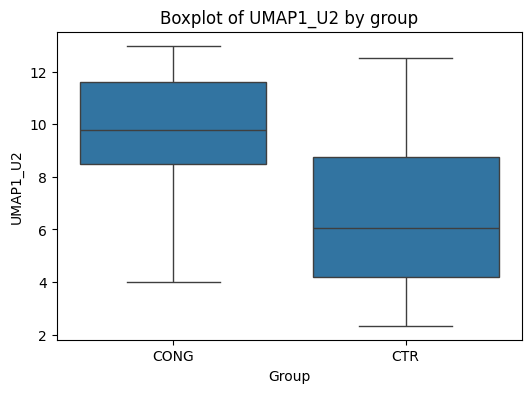

In [84]:
#############  Group-level difference plots  #############
# Boxplot by group
plt.figure(figsize=(6,4))
sns.boxplot(x="Group", y="UMAP1_U2", data=missing_hem_congControl_rightHem)
plt.title("Boxplot of UMAP1_U2 by group")
plt.show()

C:\Users\joyca\AppData\Local\Temp\ipykernel_44740\3049691381.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


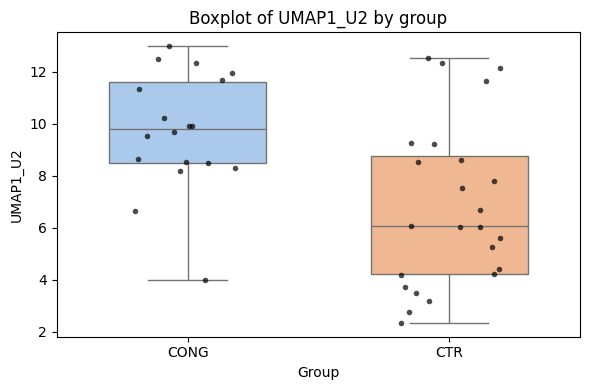

In [85]:
# Boxplot with data points
plt.figure(figsize=(6, 4))

# Boxplot
sns.boxplot(
    x="Group",
    y="UMAP1_U2",
    data=missing_hem_congControl_rightHem,
    palette="pastel",
    width=0.6
)

# Overlay points
sns.stripplot(
    x="Group",
    y="UMAP1_U2",
    data=missing_hem_congControl_rightHem,
    color="black",
    size=4,
    jitter=0.2,
    alpha=0.7
)

plt.title("Boxplot of UMAP1_U2 by group")
plt.xlabel("Group")
plt.ylabel("UMAP1_U2")
plt.tight_layout()
plt.show()


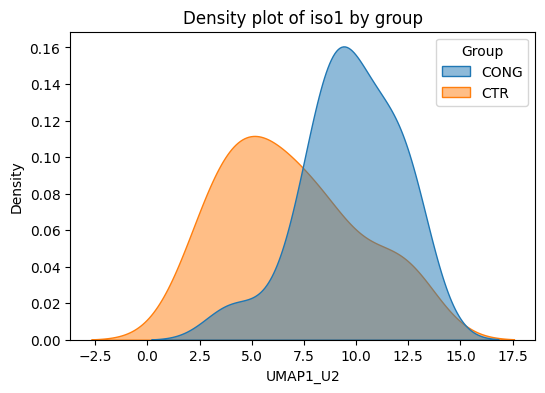

In [86]:
# Density plot: distributions by group
plt.figure(figsize=(6,4))
sns.kdeplot(data=missing_hem_congControl_rightHem, x="UMAP1_U2", hue="Group", fill=True, common_norm=False, alpha=0.5)
plt.title("Density plot of iso1 by group")
plt.show()

In [87]:
#############  Variability comparison  #############
# p < 0.05 → significant difference in variances (one group more variable).
# p ≥ 0.05 → no evidence that variances differ.
    
from scipy.stats import levene, fligner

# Split the data into groups
cong_values = missing_hem_congControl_rightHem.loc[missing_hem_congControl_rightHem["Group"] == "CONG", "UMAP1_U2"].dropna()
ctr_values  = missing_hem_congControl_rightHem.loc[missing_hem_congControl_rightHem["Group"] == "CTR", "UMAP1_U2"].dropna()

# Levene’s test (sensitive to non-normality, but widely used)
lev_stat, lev_p = levene(cong_values, ctr_values, center='median')
print(f"Levene’s test: W = {lev_stat:.3f}, p = {lev_p:.3g}")

# Fligner-Killeen test (robust against non-normality)
fl_stat, fl_p = fligner(cong_values, ctr_values)
print(f"Fligner-Killeen test: X² = {fl_stat:.3f}, p = {fl_p:.3g}")

Levene’s test: W = 2.332, p = 0.135
Fligner-Killeen test: X² = 2.601, p = 0.107


In [109]:
#############  Within-subject asymmetry tests  #############
# Test whether asymmetry differs between one-handers and controls

shape_measures = ['UMAP1_U2_asy','UMAP1_U2_LRasy'] # 'iso1', 'UMAP1_U2'

# Dictionary to store results
model_results = {}

for measure in shape_measures:
    formula = f'{measure} ~ Group + AgeScan + Gender + Study'
    
    model = smf.ols(formula, data=missing_hem_congControl).fit()
    model_results[measure] = model
    print(f'========================= Results for {measure} ===========================')
    print(model.summary())
    print('\n')

========================= Results for UMAP1_U2_asy ===========================
                            OLS Regression Results                            
Dep. Variable:           UMAP1_U2_asy   R-squared:                       0.179
Model:                            OLS   Adj. R-squared:                  0.131
Method:                 Least Squares   F-statistic:                     3.713
Date:                Tue, 07 Oct 2025   Prob (F-statistic):            0.00859
Time:                        10:59:57   Log-Likelihood:               -0.64738
No. Observations:                  73   AIC:                             11.29
Df Residuals:                      68   BIC:                             22.75
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------

C:\Users\joyca\AppData\Local\Temp\ipykernel_44740\864706353.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


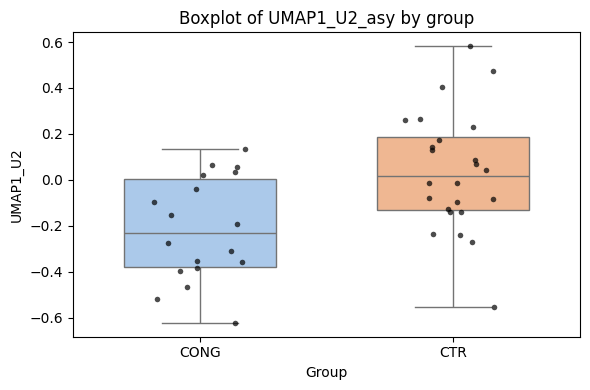

In [111]:
# Boxplot with data points
plt.figure(figsize=(6, 4))

# Boxplot
sns.boxplot(
    x="Group",
    y="UMAP1_U2_asy",
    data=missing_hem_congControl_rightHem,
    palette="pastel",
    width=0.6
)

# Overlay points
sns.stripplot(
    x="Group",
    y="UMAP1_U2_asy",
    data=missing_hem_congControl_rightHem,
    color="black",
    size=4,
    jitter=0.2,
    alpha=0.7
)

plt.title("Boxplot of UMAP1_U2_asy by group")
plt.xlabel("Group")
plt.ylabel("UMAP1_U2")
plt.tight_layout()
plt.show()


In [127]:
#############  Individual-level “predisposition” tests  #############
# if specific individuals are unusually curvy relative to population norms: Normative z-scores

# Fit normative regression using CONTROLS only
model = smf.ols("UMAP1_U2 ~ AgeScan + Gender + Study", data=controls).fit()

# Predict for all subjects
merged_info['predicted'] = model.predict(merged_info)             

# Compute residuals (observed - predicted)
merged_info["residual"] = merged_info["UMAP1_U2"] - merged_info["predicted"]

# Compute z-scores of residuals relative to control distribution
resid_mean = merged_info.loc[merged_info["Group"] == "CTR", "residual"].mean()
resid_std = merged_info.loc[merged_info["Group"] == "CTR", "residual"].std()
merged_info["z_score"] = (merged_info["residual"] - resid_mean) / resid_std

# Flag outliers
merged_info["outlier"] = merged_info["z_score"].abs() > 2  # |z| > 2 threshold
# Inspect results
# Show all rows
pd.set_option("display.max_rows", None)

print(merged_info[["Group", "UMAP1_U2", "predicted", "residual", "z_score", "outlier"]])

# Reset back to default afterwards
pd.reset_option("display.max_rows")

####  count proportion of outliers in each group and test with Fisher’s exact test  ####
from scipy.stats import fisher_exact

# Subset to just Control vs CONG
subset = merged_info[merged_info["Group"].isin(["CTR", "CONG"])]

# Build 2x2 contingency table: rows = group, cols = outlier (True/False)
table = pd.crosstab(subset["Group"], subset["outlier"])

print("Contingency table:\n", table)

# Run Fisher’s exact test
oddsratio, p = fisher_exact(table)
print("Odds ratio:", oddsratio)
print("Fisher exact test p =", p)


    Group   UMAP1_U2  predicted  residual   z_score  outlier
0    CONG   8.667238   6.235152  2.432086  0.912699    False
1    CONG   3.900392   6.127314 -2.226922 -0.835706    False
2    CONG   2.954251   7.064531 -4.110280 -1.542481    False
3    CONG   5.980019   6.956693 -0.976674 -0.366520    False
4    CONG   8.902392   6.126972  2.775420  1.041543    False
5    CONG   4.829184   6.559692 -1.730508 -0.649415    False
6    CONG   9.414864   6.235152  3.179712  1.193263    False
7    CONG   4.705130   6.920633 -2.215503 -0.831421    False
8    CONG  10.841714   7.353352  3.488362  1.309092    False
9     AMP   9.248167   7.028471  2.219696  0.832994    False
10   CONG   9.342570   6.848513  2.494057  0.935955    False
11    AMP   9.731817   7.100591  2.631226  0.987431    False
12   CONG  10.732153   6.956693  3.775460  1.416832    False
13    AMP   5.760208   7.064531 -1.304323 -0.489479    False
14    AMP   8.408195   6.884231  1.523964  0.571904    False
15   CONG   4.108644   6

In [15]:
# chi-square test of independence for MA bins
from scipy.stats import chi2_contingency

table = [
    [38, 6, 4], # controls
    [8, 10, 7] # congenitals
]
table = np.array(table)


chi2, p, dof, expected = chi2_contingency(table)
print("Chi-square:", chi2)
print("p-value:", p)

## residuals
chi2, p, dof, expected = chi2_contingency(table)
residuals = (table - expected) / expected**0.5
print(residuals)

## effect size
chi2, p, dof, expected = chi2_contingency(table)
n = table.sum()
k = min(table.shape)  # min(num_rows, num_cols)
cramers_v = np.sqrt(chi2 / (n * (k - 1)))
print("Cramér's V:", cramers_v)

Chi-square: 15.69481966403162
p-value: 0.0003907627998694069
[[ 1.40979338 -1.39370834 -1.20208066]
 [-1.95346701  1.93117893  1.66565183]]
Cramér's V: 0.46367826091404024


In [11]:
########  same as above, with a helper function ########
## calculate multiple contingency tables

from scipy.stats import chi2_contingency, fisher_exact

def chi_square_report(table, name=""):
    table = np.array(table)   # convert to NumPy array
    
    # Handle special case: if 2x2, also compute Fisher's exact test
    use_fisher = table.shape == (2,2)
    
    chi2, p, dof, expected = chi2_contingency(table)
    
    # Standardized residuals
    residuals = (table - expected) / np.sqrt(expected)
    
    # Cramér’s V
    n = table.sum()
    k = min(table.shape)
    cramers_v = np.sqrt(chi2 / (n * (k - 1)))
    
    print(f"\n=== {name} ===")
    print(f"Chi-square: {chi2:.3f}")
    print(f"p-value: {p:.4g}")
    print(f"Degrees of freedom: {dof}")
    print(f"Cramér's V: {cramers_v:.3f}")
    print("Standardized residuals:\n", np.round(residuals, 2))
    
    if use_fisher:
        oddsratio, fisher_p = fisher_exact(table)
        print(f"Fisher's Exact Test p-value: {fisher_p:.4g}")

# Your tables
tableWhole = [
    [38, 6, 4],  # controls
    [8, 10, 7]   # congenitals/patients
]
tableLeftHem = [
    [19, 5],  # controls (dropped zero column)
    [2, 5]    # congenitals
]
tableRightHem = [
    [19, 1, 4],  # controls
    [6, 5, 7]    # congenitals
]

# Run reports
chi_square_report(tableWhole, "Whole brain")
chi_square_report(tableLeftHem, "Left hemisphere")
chi_square_report(tableRightHem, "Right hemisphere")



=== Whole brain ===
Chi-square: 15.695
p-value: 0.0003908
Degrees of freedom: 2
Cramér's V: 0.464
Standardized residuals:
 [[ 1.41 -1.39 -1.2 ]
 [-1.95  1.93  1.67]]

=== Left hemisphere ===
Chi-square: 4.244
p-value: 0.03938
Degrees of freedom: 1
Cramér's V: 0.370
Standardized residuals:
 [[ 0.68 -0.99]
 [-1.26  1.82]]
Fisher's Exact Test p-value: 0.02185

=== Right hemisphere ===
Chi-square: 9.583
p-value: 0.008299
Degrees of freedom: 2
Cramér's V: 0.478
Standardized residuals:
 [[ 1.25 -1.31 -0.91]
 [-1.44  1.51  1.05]]
